# GridForecast: Electricity Demand Predictor

GridForecast is an end-to-end electricity demand forecasting system built on real-time ENTSO-E operational data, combining time series analytics (ARIMA, SARIMA, Prophet, LSTM), ensemble modeling, automated monitoring, and continuous retraining to enable data-driven grid operations and energy trading decisions.

From insights derived from temporal demand patterns and renewable energy variability, actionable forecasting models were developed and deployed via an interactive web application. The application provides a dashboard interface for grid operators and energy traders to visualize 24-hour demand predictions, confidence intervals, and real-time model performance to support operational planning and risk mitigation.

## Dataset

The objective of the project is to predict the Electricity Demand in Germany. So we need to collect the data using API from the ENTSO-E Transparency Platform. 
ENTSO-E Transparency Platform gives access to electricity generation, transportation, and consumption data for the pan-European market. It is having the details from the countries like Austria, Belgium, Switzerland, Denmark, Germany, Spain, France, UK, Italy, Ireland, Luxembourg, the Netherlands, Norway, Portugal, and Sweden. 

In order to get access to API, we need to register in the website - 
[https://transparency.entsoe.eu/](https://transparency.entsoe.eu/). 

For complete details, kindly refer the link - 
[https://transparencyplatform.zendesk.com/hc/en-us/articles/12845911031188-How-to-get-security-token](https://transparencyplatform.zendesk.com/hc/en-us/articles/12845911031188-How-to-get-security-token). 

How to fetch the dataset is given in detail in the link - [https://transparencyplatform.zendesk.com/hc/en-us/articles/15696643163924-Request-Methods](https://transparencyplatform.zendesk.com/hc/en-us/articles/15696643163924-Request-Methods). 


Apart from this traditional methods, they are providing the library to fetch the data using API - [https://github.com/EnergieID/entsoe-py](https://github.com/EnergieID/entsoe-py). 

We will be using this library because of convenience. 

## Import libraries and setup

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
from datetime import date, timedelta
import time 
import requests
from entsoe import EntsoePandasClient
from dateutil.relativedelta import relativedelta


## Loading the API Key 

In [2]:
# Loading the API key from env file 

load_dotenv()
API_KEY = os.getenv('ENTSOE_API_KEY')

if not API_KEY:
    print("ERROR: ENTSOE_API_KEY not found")

else:
    print(f"API Key loaded successfully")


API Key loaded successfully


# Fetching data

In [3]:
# Class for downloading the dataset from the website using API. 

class GermanyElectricityDownloader:
    def __init__(self, api_key):
        """
        Initialize with ENTSO-E API key 
        """
        self.client = EntsoePandasClient(api_key=api_key)        
        self.time_zone = 'Europe/Berlin'
        self.country_code_old = 'DE_AT_LU'  # 2015 - 2018
        self.country_code_new = 'DE_LU'     # 2019 onwards

    def _get_country_code(self, year):
        """Return the appropriate country code based on the year."""
    
        return self.country_code_old if year <= 2018 else self.country_code_new

    def _fetch_with_retry(self, name, func, retries=3, delay=5):
        """Fetch a single query with retry logic."""
        for attempt in range(1, retries + 1):
            # Retrying the fetching to bypass the temporary network/API failure
            try:
                # print(f"Fetching: {name} (attempt {attempt})")
                df = func()
                time.sleep(1)  
                return df
            except Exception as e:
                if attempt == retries:
                    print(f"Failed to fetch '{name}' after {retries} attempts: {e}")
                    return None
                print(f"Attempt {attempt} failed for '{name}': {e}. Retrying in {delay}s...")
                time.sleep(delay)
        return None

    
    def download_all(self, start_date, end_date):
        """Download complete dataset for demand prediction
        
        Args:
            start_date : Starting date for which data need to be fetched. 
            end_date : Ending date for which data need to be fetched. 
        Return: 
            Combined DataFrame will returned by concatenating all the DataFrame generated. 
        """
        

        print(f"Downloading complete dataset for demand prediction from {start_date} to {end_date}")
        
        try:
            start = pd.Timestamp(start_date, tz=self.time_zone)
            end = pd.Timestamp(end_date, tz=self.time_zone) + pd.Timedelta(minutes=30)

            start_year = start.year
            end_year = end.year

            all_year_dfs = []

            for year in range(start_year, end_year + 1):
                country_code = self._get_country_code(year)
                year_start = max(
                        pd.Timestamp(f'{year}-01-01', tz=self.time_zone),
                        start
                    )
                year_end = min(
                        pd.Timestamp(f'{year+1}-01-01', tz=self.time_zone),
                        end
                    )

                # Code from https://github.com/EnergieID/entsoe-py library for downloading the data via API
                time_series_queries = {
                    "load": lambda: self.client.query_load(
                        country_code, start=year_start, end=year_end),

                    "wind_and_solar_forecast": lambda: self.client.query_wind_and_solar_forecast(
                        country_code, start=year_start, end=year_end, psr_type=None),

                    "intraday_wind_and_solar_forecast": lambda: self.client.query_intraday_wind_and_solar_forecast(
                        country_code, start=year_start, end=year_end, psr_type=None),

                    "generation": lambda: self.client.query_generation(
                        country_code, start=year_start, end=year_end, psr_type=None),

                    "import": lambda: self.client.query_import(
                        country_code, start=year_start, end=year_end),

                    "generation_import": lambda: self.client.query_generation_import(
                        country_code, year_start, year_end),
                }


                dfs = []

                for name, func in time_series_queries.items():
                    df = self._fetch_with_retry(name, func)

                    if df is None:
                        continue

                    df = df.sort_index()
                    if df.index.tz is None:
                        df.index = df.index.tz_localize("UTC").tz_convert(self.time_zone)
                    else:
                        df.index = df.index.tz_convert(self.time_zone)

                    if isinstance(df.columns, pd.MultiIndex):
                        df.columns = ["_".join(col).strip() for col in df.columns]

                    # Adding prefix so we get separate column names 
                    df = df.add_prefix(f"{name}_")

                    dfs.append(df)

                if dfs:
                    year_df = pd.concat(dfs, axis=1, sort=False)
                    all_year_dfs.append(year_df)

            if not all_year_dfs:
                return None

            # Combining all DataFrame to one DataFrame 
            final_df = pd.concat(all_year_dfs)
            final_df = final_df[~final_df.index.duplicated(keep='last')]



            print(f"Data Frame created with shape : {final_df.shape}")
            return final_df
        except ConnectionError as e:
            print(f"Network error: {e}")
            return None

        except pd.errors.EmptyDataError as e:
            print(f"No data returned from API: {e}")
            return None

        except Exception as e:
            print(f"Unexpected error downloading data: {e}")
            raise

    def update_data(self): 
        """Check the availability of the dataset if available update the missing and if not download the complete historical data."""

        
        # Creating the artifacts folder for saving the csv file. 
        project_root = Path.cwd().parent
        output_dir = project_root / 'artifacts/raw'
        os.makedirs(output_dir, exist_ok=True)

        # Defining the csv name 
        csv_filename = 'power_consumption_germany.csv'
        csv_file_path_str = str(output_dir / csv_filename)

        # Once the data is loaded from the website using API and when we are updating the new data we don't want to download the data again. 
        # So the check is created for checking the data and then downloading the data which pending for update. 
        if os.path.isfile(csv_file_path_str):
            # File exists then check the last date in the CSV
            existing_df = pd.read_csv(csv_file_path_str, index_col=0, parse_dates=True)
            existing_df.index = pd.to_datetime(existing_df.index, utc=True).tz_convert('Europe/Berlin')

            last_date = existing_df.index.max().date()
            today = date.today()
            yesterday = today - timedelta(days=1)

            if last_date >= yesterday:
                print(f"CSV is already up to date (last record: {last_date}). Nothing to download.")
                return

            # Download missing days from day after last record to yesterday
            fetch_start = last_date + timedelta(days=1)
            fetch_end = yesterday 

            print(f"CSV exists but is outdated. Fetching missing data: {fetch_start} to {yesterday}")

            new_data = self.download_all(
                start_date=fetch_start.strftime('%Y%m%d'),
                end_date=fetch_end.strftime('%Y%m%d')
            )
            # Adding the Data with already available data
            if new_data is not None and not new_data.empty:
                updated_df = pd.concat([existing_df, new_data])
                updated_df = updated_df[~updated_df.index.duplicated(keep='last')]  # safety dedup
                updated_df.to_csv(csv_file_path_str)
                print(f"Updated CSV with {len(new_data)} new rows. Total rows: {len(updated_df)}")
            else:
                print("No new data was returned from the API.")

        else:
            # File does not exist then do the full historical backfill
            start = pd.Timestamp('20150101', tz=self.time_zone)
            end = pd.Timestamp(date.today().strftime('%Y%m%d'), tz=self.time_zone)

            batch = 0
            all_data = []
            
            # Downloading the data in batches to avoid API failures 
            while start < end:
                batch += 1
                batch_end = min(start + relativedelta(years=1), end)
                print(f"Downloading batch {batch}: {start.date()} to {batch_end.date()-timedelta(days=1)}")
                
                data = self.download_all(
                    start_date=start.strftime('%Y%m%d'),
                    end_date=(batch_end - timedelta(days=1)).strftime('%Y%m%d')
                )
                
                if data is not None and not data.empty:
                    all_data.append(data)
                
                start = batch_end

            # Adding the full data to created a combined final dataset 
            if all_data:
                final_df = pd.concat(all_data)
                final_df = final_df[~final_df.index.duplicated(keep='last')]
                final_df.to_csv(csv_file_path_str)
                print(f"\nSuccess! Saved {len(final_df)} rows.")
            else:
                print("No data was downloaded.")



def main():
    downloader = GermanyElectricityDownloader(api_key=API_KEY)

    data = downloader.update_data()


if __name__ == "__main__":
    main()

CSV exists but is outdated. Fetching missing data: 2026-05-26 to 2026-06-06
Data Frame created with shape : (1056, 64)
Updated CSV with 1056 new rows. Total rows: 390655


In [4]:
%pwd

'f:\\Samith\\Github\\grid-forecast\\research'

In [5]:
os.chdir("../")

In [6]:
%pwd

'f:\\Samith\\Github\\grid-forecast'

In [7]:
df = pd.read_csv(r"artifacts/raw/power_consumption_germany.csv",
    index_col=0,
    parse_dates=True
)

In [8]:
df.index = pd.to_datetime(df.index, utc=True).tz_convert('Europe/Berlin')

In [9]:
df.head()

,load_Actual Load,wind_and_solar_forecast_Solar,wind_and_solar_forecast_Wind Offshore,wind_and_solar_forecast_Wind Onshore,intraday_wind_and_solar_forecast_Solar,intraday_wind_and_solar_forecast_Wind Offshore,intraday_wind_and_solar_forecast_Wind Onshore,generation_Biomass_Actual Aggregated,generation_Biomass_Actual Consumption,generation_Fossil Brown coal/Lignite_Actual Aggregated,...,generation_import_Import_PL,generation_import_Import_SE_4,generation_import_Import_SI,generation_import_Import_sum,import_BE,generation_import_Import_BE,import_AT,generation_import_Import_AT,import_NO_2,generation_import_Import_NO_2
2015-01-01 00:00:00+01:00,51873.64,0.0,258.0,7517.70,0.0,219.0,3713.0,5014.84,0.0,15858.61,...,NaN,0.0,0.0,3001.04,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:15:00+01:00,51382.96,0.0,258.0,7603.26,0.0,219.0,3789.0,5020.28,0.0,15803.40,...,NaN,0.0,0.0,3001.04,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:30:00+01:00,51444.18,0.0,259.0,7695.36,0.0,218.5,3866.0,5016.53,0.0,15649.47,...,NaN,0.0,0.0,3001.04,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:45:00+01:00,51268.75,0.0,259.0,7779.20,0.0,218.5,3942.0,5006.21,0.0,15437.69,...,NaN,0.0,0.0,3001.04,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+01:00,50869.89,0.0,259.0,8108.18,0.0,218.5,4175.5,4978.48,0.0,15552.28,...,NaN,0.0,0.0,3179.07,NaN,NaN,NaN,NaN,NaN,NaN


# Summary Statistics

Lets just see some of the basic statistics of the dataset

In [10]:
df.shape

(390655, 87)

In [11]:
df.columns

Index(['load_Actual Load', 'wind_and_solar_forecast_Solar',
       'wind_and_solar_forecast_Wind Offshore',
       'wind_and_solar_forecast_Wind Onshore',
       'intraday_wind_and_solar_forecast_Solar',
       'intraday_wind_and_solar_forecast_Wind Offshore',
       'intraday_wind_and_solar_forecast_Wind Onshore',
       'generation_Biomass_Actual Aggregated',
       'generation_Biomass_Actual Consumption',
       'generation_Fossil Brown coal/Lignite_Actual Aggregated',
       'generation_Fossil Brown coal/Lignite_Actual Consumption',
       'generation_Fossil Coal-derived gas_Actual Aggregated',
       'generation_Fossil Coal-derived gas_Actual Consumption',
       'generation_Fossil Gas_Actual Aggregated',
       'generation_Fossil Gas_Actual Consumption',
       'generation_Fossil Hard coal_Actual Aggregated',
       'generation_Fossil Hard coal_Actual Consumption',
       'generation_Fossil Oil_Actual Aggregated',
       'generation_Fossil Oil_Actual Consumption',
       'generat

In [12]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 390655 entries, 2015-01-01 00:00:00+01:00 to 2026-06-03 23:00:00+02:00
Data columns (total 87 columns):
 #   Column                                                         Non-Null Count   Dtype  
---  ------                                                         --------------   -----  
 0   load_Actual Load                                               390630 non-null  float64
 1   wind_and_solar_forecast_Solar                                  390643 non-null  float64
 2   wind_and_solar_forecast_Wind Offshore                          390559 non-null  float64
 3   wind_and_solar_forecast_Wind Onshore                           390643 non-null  float64
 4   intraday_wind_and_solar_forecast_Solar                         390559 non-null  float64
 5   intraday_wind_and_solar_forecast_Wind Offshore                 390655 non-null  float64
 6   intraday_wind_and_solar_forecast_Wind Onshore                  390421 non-null  float64
 7   generation_B

Dataset is having null values as expected. Need to explore more to get insights.

In [13]:
df.index.min(), df.index.max()

(Timestamp('2015-01-01 00:00:00+0100', tz='Europe/Berlin'),
 Timestamp('2026-06-05 23:45:00+0200', tz='Europe/Berlin'))

In [14]:
df.index.tz

zoneinfo.ZoneInfo(key='Europe/Berlin')

In [15]:
df.index.is_monotonic_increasing

False

In [16]:
df.describe()

,load_Actual Load,wind_and_solar_forecast_Solar,wind_and_solar_forecast_Wind Offshore,wind_and_solar_forecast_Wind Onshore,intraday_wind_and_solar_forecast_Solar,intraday_wind_and_solar_forecast_Wind Offshore,intraday_wind_and_solar_forecast_Wind Onshore,generation_Biomass_Actual Aggregated,generation_Biomass_Actual Consumption,generation_Fossil Brown coal/Lignite_Actual Aggregated,...,generation_import_Import_PL,generation_import_Import_SE_4,generation_import_Import_SI,generation_import_Import_sum,import_BE,generation_import_Import_BE,import_AT,generation_import_Import_AT,import_NO_2,generation_import_Import_NO_2
count,390630.000000,390643.000000,390559.000000,390643.000000,390559.000000,390655.000000,390421.000000,390654.000000,131141.0,390654.000000,...,390460.000000,390652.000000,131141.000000,390655.000000,268006.000000,293501.000000,191688.000000,259514.000000,201047.000000,201048.000000
mean,58634.750458,5787.471878,2402.404601,10945.133564,5058.352026,2378.295376,9572.265915,4521.404262,0.0,11493.318976,...,42.141077,254.148925,27.886841,4229.770000,333.580294,306.952052,651.472105,594.728990,655.738216,655.741040
std,11404.161130,9122.623889,1829.286998,8797.957257,8779.523613,1824.630352,8799.849698,403.590738,0.0,4085.613348,...,169.544947,263.500192,101.119105,3162.211333,397.982807,390.310250,587.754007,563.802523,536.283905,536.284058
min,28308.000000,0.000000,1.000000,151.000000,0.000000,1.000000,0.000000,3084.200000,0.0,1337.332000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49712.690000,0.000000,754.010000,4226.610000,0.000000,765.645000,3053.000000,4235.870000,0.0,8495.519065,...,0.000000,0.000000,0.000000,1893.990000,0.000000,0.000000,202.090975,171.084375,0.000000,0.000000
50%,57928.900000,174.290000,2059.910000,8304.810000,111.940000,1985.680000,6644.820000,4551.920000,0.0,12156.840000,...,0.000000,171.700000,0.000000,3917.560000,140.560536,118.850000,467.820000,410.425000,687.040000,687.040000
75%,66846.151535,9045.285000,3860.680000,15326.597205,6247.370000,3782.000000,13249.260000,4812.097500,0.0,14844.947500,...,0.000000,585.030000,0.000000,5933.660000,658.187500,567.010000,940.716500,850.230000,1173.440000,1173.447500
max,92417.840000,57206.814350,7541.930000,46982.427710,55484.071090,7575.830000,47539.960000,5402.040000,0.0,19826.840000,...,2636.730000,720.000000,1114.880000,18824.990000,1300.570000,1300.570000,3860.824000,3860.824000,1408.320000,1408.320000


In [17]:
pd.set_option('display.max_rows', None)
df.isnull().sum().sort_values(ascending=False)

import_IT_NORD                                                   365477
import_IT_NORD_AT                                                365149
import_SI                                                        357869
generation_Fossil Coal-derived gas_Actual Consumption            286013
generation_import_Import_IT_NORD_AT                              285718
generation_Fossil Brown coal/Lignite_Actual Consumption          285718
generation_Nuclear_Actual Consumption                            281716
import_SE_4                                                      275343
import_FR                                                        263542
generation_Waste_Actual Consumption                              259610
generation_Other renewable_Actual Consumption                    259609
generation_Hydro Run-of-river and poundage_Actual Consumption    259514
generation_import_Import_IT_NORD                                 259514
generation_Other_Actual Consumption                             

As we noticed earlier there are null values and some of the columns are having large number of null values. 

In [18]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "present_count": df.notnull().sum(),
})
missing = missing.sort_values("missing_pct", ascending=False)
missing = missing[missing["missing_pct"]>0]
missing

,missing_count,missing_pct,present_count
import_IT_NORD,365477,93.55,25178
import_IT_NORD_AT,365149,93.47,25506
import_SI,357869,91.61,32786
generation_Fossil Coal-derived gas_Actual Consumption,286013,73.21,104642
generation_import_Import_IT_NORD_AT,285718,73.14,104937
generation_Fossil Brown coal/Lignite_Actual Consumption,285718,73.14,104937
generation_Nuclear_Actual Consumption,281716,72.11,108939
import_SE_4,275343,70.48,115312
import_FR,263542,67.46,127113
generation_Waste_Actual Consumption,259610,66.46,131045


This is the exact list of missing values with percentages. 

In [19]:
df.duplicated().sum()

np.int64(0)

There is no duplicate records. 

# Exploratory Data Analysis

Let's explore the Data

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

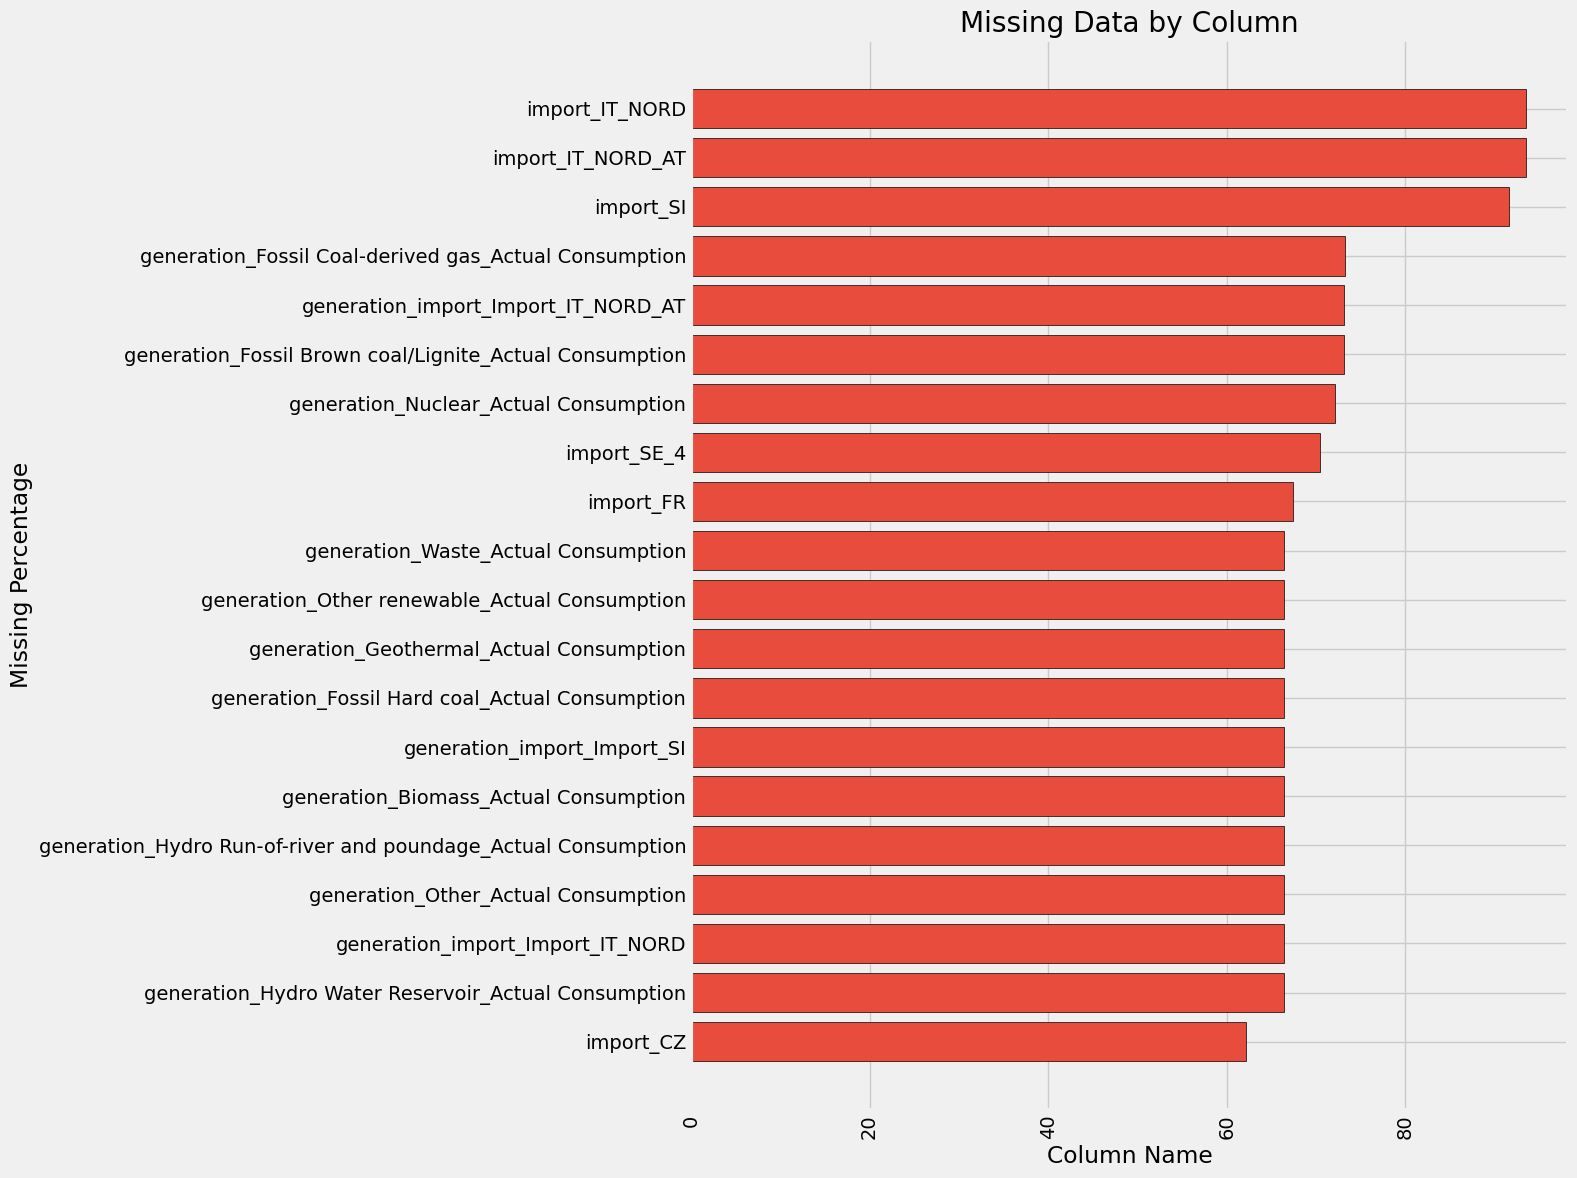

In [21]:
plt.figure(figsize=(16, 12))
top_missing = missing[missing["missing_pct"] > 0].head(20)
top_missing_sorted = top_missing.sort_values('missing_pct', ascending=True)
plt.barh(top_missing_sorted.index, top_missing_sorted["missing_pct"], color='#e74c3c', edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel("Column Name")
plt.ylabel("Missing Percentage")
plt.title("Missing Data by Column")
plt.tight_layout()
plt.show()

We need to decide whether we need to keep these columns or not. Very high percentage of data is missing. 

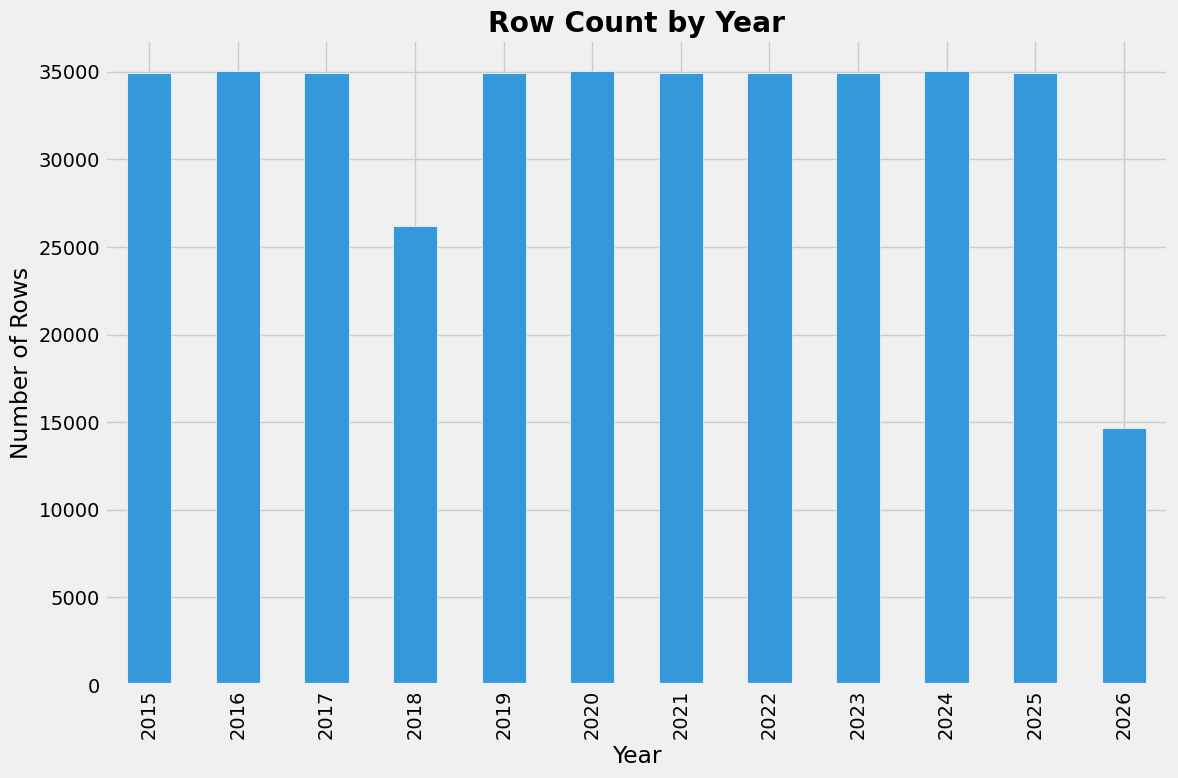

In [22]:
df_year = df.copy()
df_year['year'] = df_year.index.year
year_counts = df_year.groupby("year").size()

fig = plt.figure(figsize=(12, 8))
year_counts.plot(kind="bar", color="#3498db", edgecolor="white")
plt.xlabel("Year")
plt.ylabel("Number of Rows")    
plt.title("Row Count by Year", fontweight="bold")
plt.tight_layout()
plt.show()

This plot confirms that dataset is having no details for the later period of 2018. 

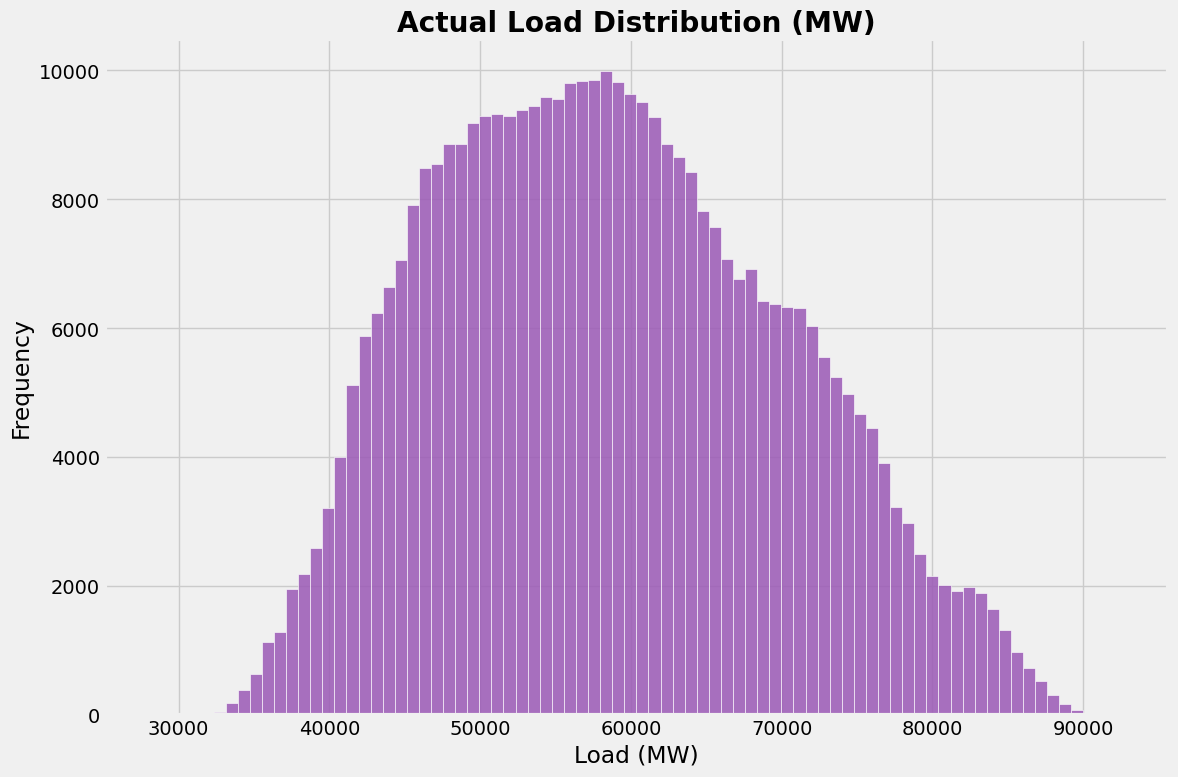

In [23]:
plt.figure(figsize=(12, 8))

df["load_Actual Load"].dropna().hist(bins=80, color="#9b59b6", edgecolor="white", alpha=0.85)
plt.xlabel("Load (MW)")
plt.ylabel("Frequency")
plt.title("Actual Load Distribution (MW)", fontweight="bold")
plt.tight_layout()
plt.show()

Load demand is relatively stable over years with natural seasonal variation

In [24]:
TARGET = "load_Actual Load"

df['hour'] = df.index.hour
df['minute'] = df.index.minute
df['time_of_day'] = df['hour'] + df['minute']/60
df['month'] = df.index.month
df["day_of_week"] = df.index.dayofweek
df["year"]        = df.index.year
df["is_weekend"]  = df.index.dayofweek >= 5

DAY_NAMES   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

sns.set_theme(style="whitegrid", palette="muted")

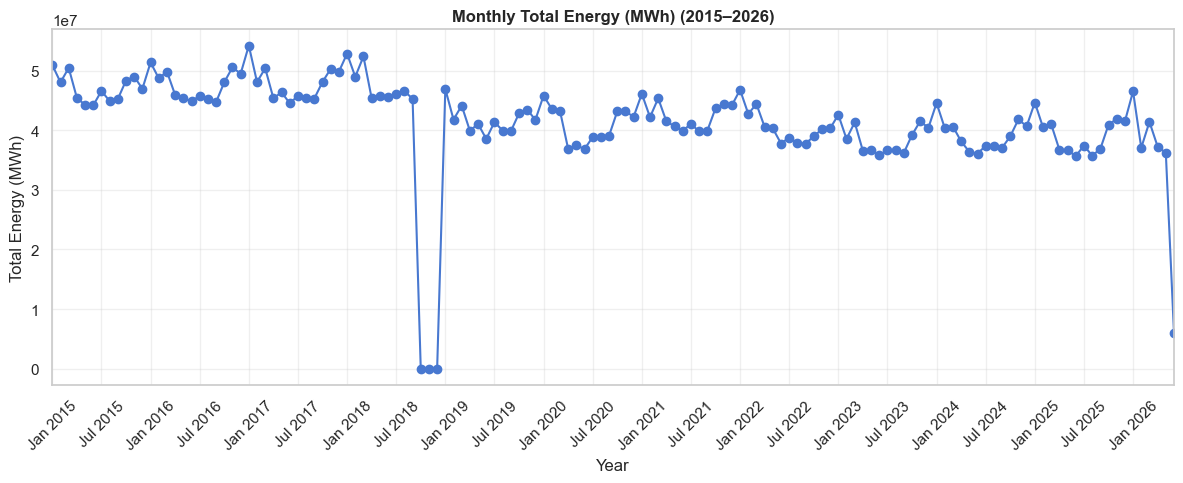

In [25]:
monthly_energy  = (df['load_Actual Load'].resample('ME').sum().mul(0.25))

plt.figure(figsize=(12,5))

ax = monthly_energy.plot(marker='o')

ax.set_title("Monthly Total Energy (MWh) (2015–2026)", fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Total Energy (MWh)")
ax.grid(alpha=0.3)


ax.set_xticks(monthly_energy.index[::6]) 
ax.set_xticklabels(
    monthly_energy.index.strftime('%b %Y')[::6],
    rotation=45
)

plt.tight_layout()
plt.show()

Monthly total energy generally fluctuates between about 40–50 million MWh, with a mild seasonal pattern and no strong long‑term upward or downward trend overall. There is a sharp data anomaly around mid‑2018 where the energy value drops to nearly zero for a couple of months, suggesting missing or erroneous data rather than a real system change. After 2019, the variability appears slightly lower and the series stabilizes in the low‑40 million MWh range, with occasional peaks but no sustained growth or decline through early 2026

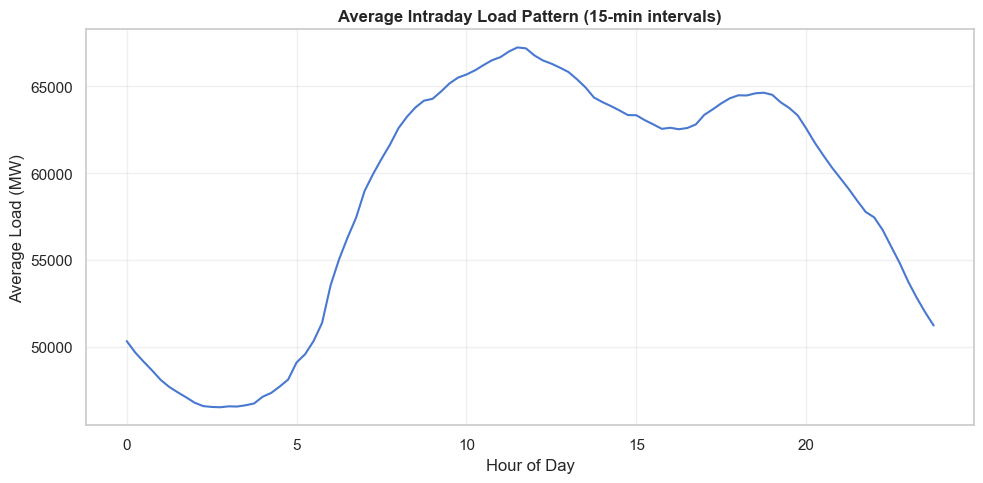

In [26]:

daily_pattern = df.groupby('time_of_day')['load_Actual Load'].mean()

plt.figure(figsize=(10,5))
daily_pattern.plot()

plt.title("Average Intraday Load Pattern (15-min intervals)", fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This indicates a typical workday pattern with strong daytime demand and lighter overnight usage.

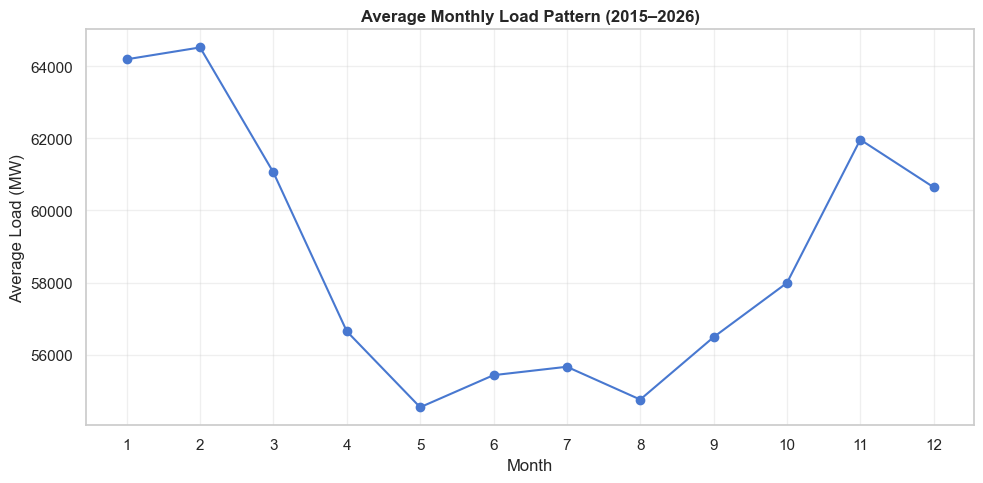

In [27]:


monthly_seasonality = (
    df.groupby('month')['load_Actual Load']
      .mean()
)

plt.figure(figsize=(10,5))
monthly_seasonality.plot(marker='o')

plt.title("Average Monthly Load Pattern (2015–2026)", fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average Load (MW)")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This indicates a seasonal pattern. Usage is high in the month of Jan- Feb and it is lowest during the Month May -Aug and gradually increasing towards Nov. 

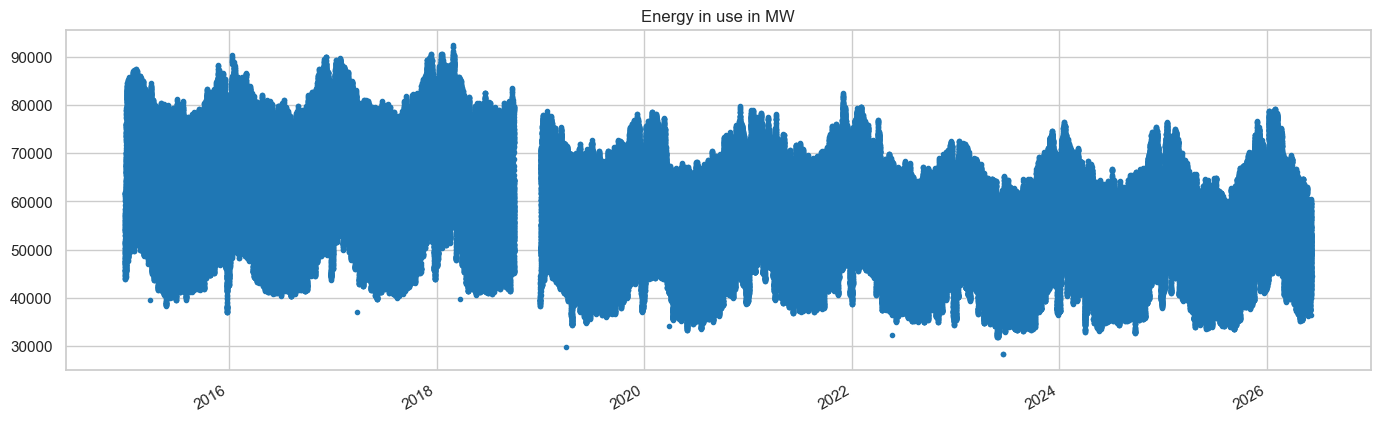

In [28]:
df['load_Actual Load'].plot(style='.', figsize=(15,5), color=color_pal[0], title='Energy in use in MW')
plt.show()

This clearly shows there is structural break from Jan 2019  and data is missing in 2018 end. Missing is mostly from oct 2018 - dec 2018

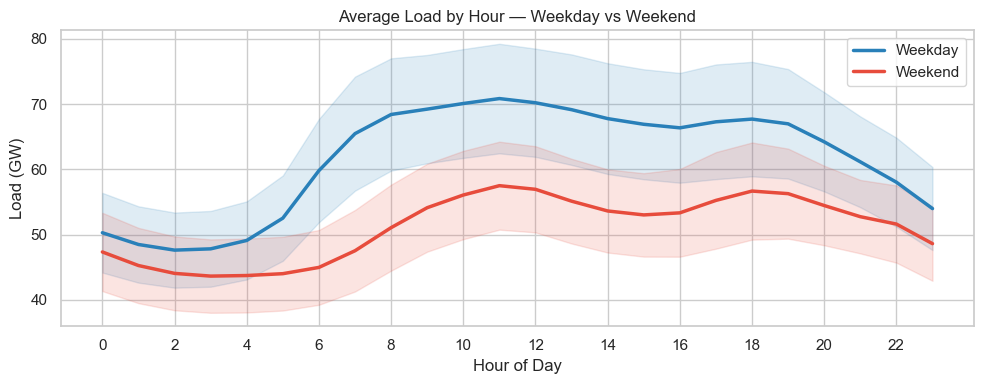

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
for is_wknd, label, color in [(False, "Weekday", "#2980b9"), (True, "Weekend", "#e74c3c")]:
    grp  = df[df["is_weekend"] == is_wknd].groupby("hour")[TARGET]
    mean = grp.mean() / 1000
    std  = grp.std()  / 1000
    ax.plot(mean.index, mean.values, label=label, color=color, lw=2.5)
    ax.fill_between(mean.index, mean - std, mean + std, alpha=0.15, color=color)
ax.set(title="Average Load by Hour — Weekday vs Weekend",
       xlabel="Hour of Day", ylabel="Load (GW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

There more usage during the Weekday than Weekend. 

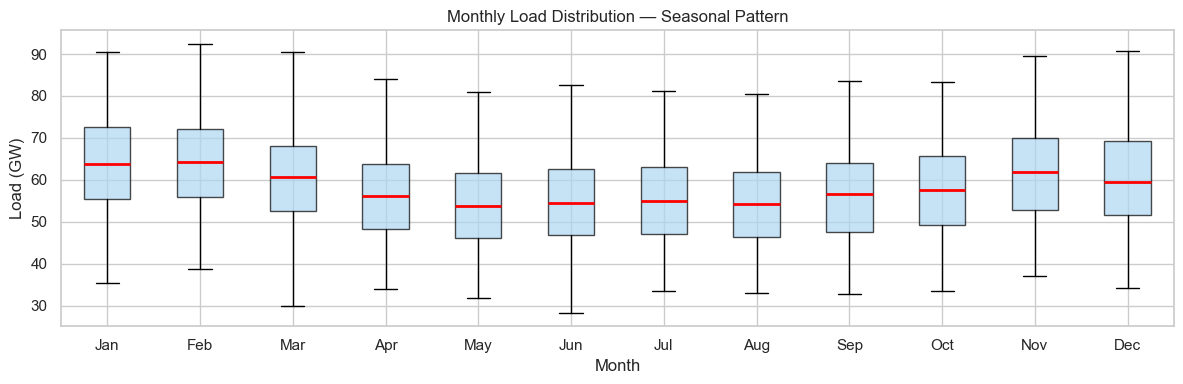

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))
month_data = [df[df["month"] == m][TARGET].dropna().values / 1000 for m in range(1, 13)]
ax.boxplot(month_data, labels=MONTH_NAMES, showfliers=False,
           medianprops=dict(color="red", lw=2),
           patch_artist=True,
           boxprops=dict(facecolor="#aed6f1", alpha=0.7))
ax.set(title="Monthly Load Distribution — Seasonal Pattern",
       xlabel="Month", ylabel="Load (GW)")
plt.tight_layout()
plt.show()

This is the similar insights about the seasonality we have received before. 

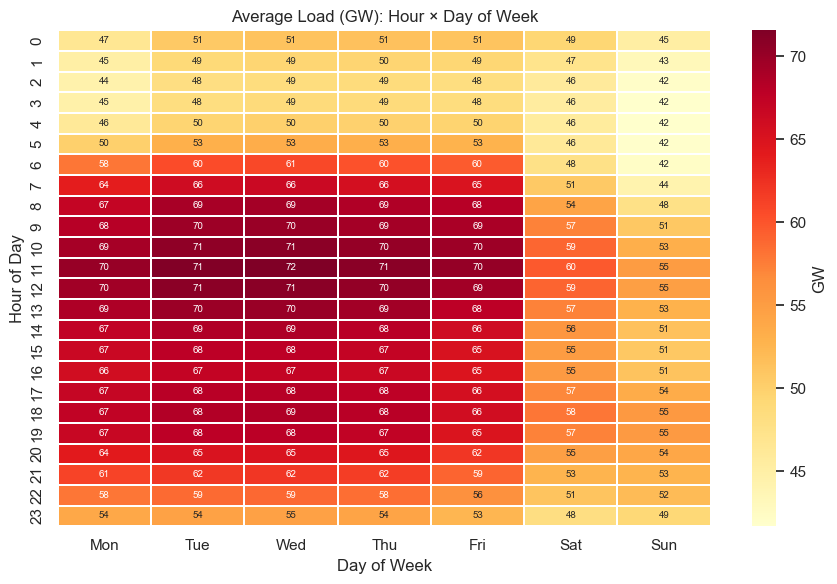

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
pivot = df.groupby(["hour", "day_of_week"])[TARGET].mean().unstack() / 1000
pivot.columns = DAY_NAMES
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", fmt=".0f", annot=True,
            annot_kws={"size": 7}, linewidths=0.3, cbar_kws={"label": "GW"})
ax.set(title="Average Load (GW): Hour × Day of Week",
       xlabel="Day of Week", ylabel="Hour of Day")
plt.tight_layout()
plt.show()


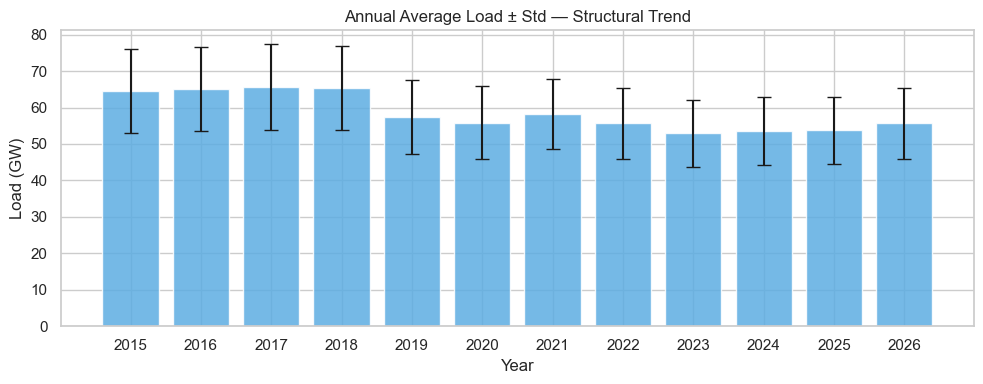

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
annual = df.groupby("year")[TARGET].agg(["mean", "std"]) / 1000
ax.bar(annual.index, annual["mean"], yerr=annual["std"],
       color="#5dade2", edgecolor="white", capsize=5, alpha=0.85)
ax.set(title="Annual Average Load ± Std — Structural Trend",
       xlabel="Year", ylabel="Load (GW)")
ax.set_xticks(annual.index)
plt.tight_layout()
plt.show()

This shows there is a structural shift from 2019 onwards.

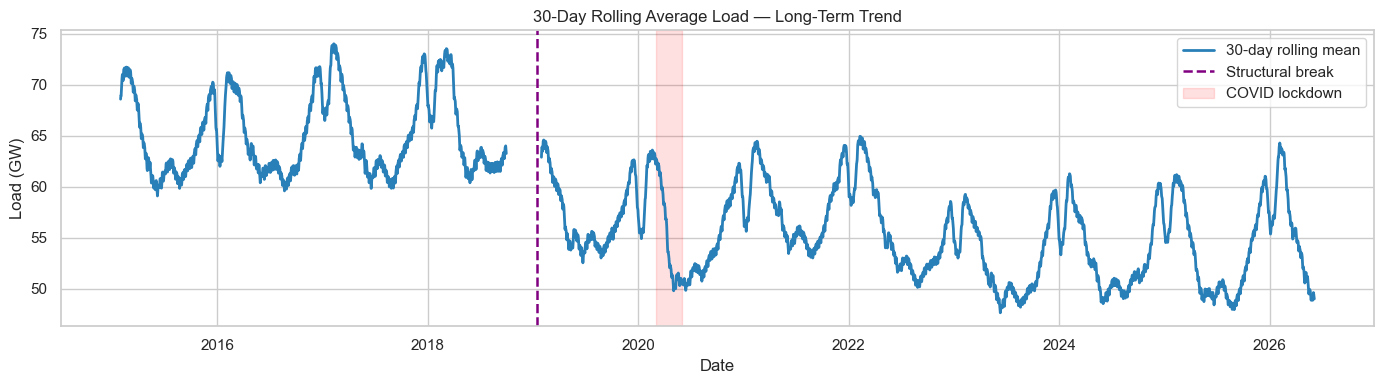

In [33]:
fig, ax = plt.subplots(figsize=(14, 4))
daily = df[TARGET].resample("D").mean() / 1000
ax.plot(daily.rolling(30).mean(), color="#2980b9", lw=2, label="30-day rolling mean")
ax.axvline(pd.Timestamp("2019-01-15"), color="purple", lw=1.8,
           ls="--", label="Structural break")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"),
           alpha=0.12, color="red", label="COVID lockdown")
ax.set(title="30-Day Rolling Average Load — Long-Term Trend",
       xlabel="Date", ylabel="Load (GW)")
ax.legend()
plt.tight_layout()
plt.show()

This shows everything, the missing values in 2018 end, Structural shift after 2019 and also the dip during the COVID lockdown. 

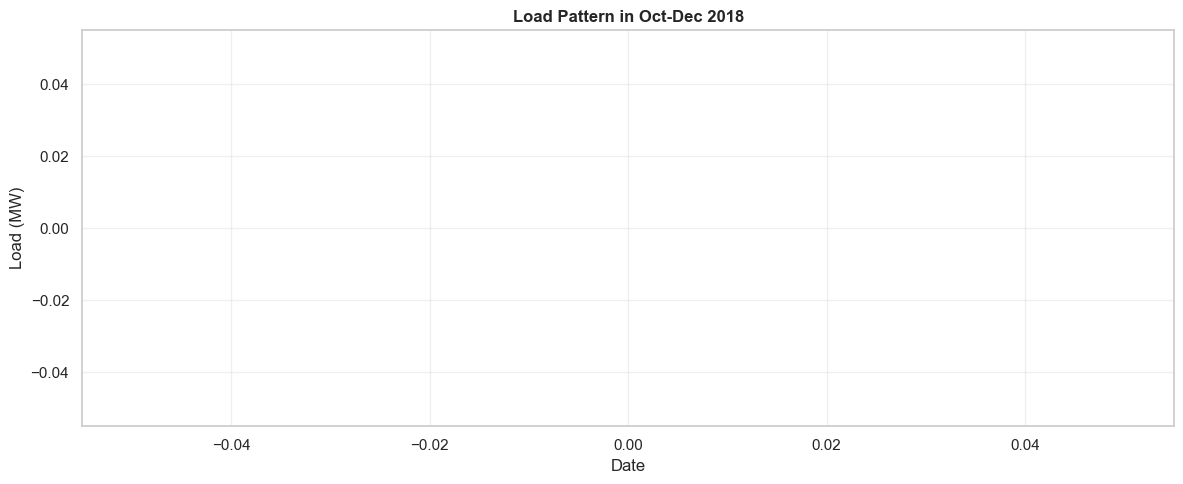

In [34]:
df_2018 = df[df.index.year == 2018]
df_2018_oct_dec = df_2018[df_2018.index.month.isin([10, 11, 12])]
plt.figure(figsize=(12, 5))
plt.plot(df_2018_oct_dec.index, df_2018_oct_dec[TARGET], label='2018')  
plt.title("Load Pattern in Oct-Dec 2018", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()      
plt.show()

This confirms there is no data available in the month of oct - dec 2018 

In [35]:
df_2018['load_Actual Load'].isnull().sum() == df['load_Actual Load'].isnull().sum()

np.False_

Data prior to 2019 was excluded due to a structural break and a substantial missing target period in late 2018. Since the missingness affects the target variable, imputation was avoided to prevent introducing artificial patterns into the forecasting task.

In [36]:
%pwd

'f:\\Samith\\Github\\grid-forecast'

In [37]:
output_dir = 'artifacts/data'
os.makedirs(output_dir, exist_ok=True)
df_clean = df[df.index >= '2019-01-01'].copy()
df_clean.to_parquet(output_dir + '/power_consumption_2019_onwards.parquet') 

# Data Cleaning and Preprocessing 

Let's clean the dataset and drop the columns with 40 % missing rate. 

In [38]:
threshold = 0.40
cols_to_drop = df_clean[df_clean.columns[df_clean.isnull().mean() > threshold]].columns
df_clean.drop(columns=cols_to_drop, inplace=True)
df_clean.shape

(259514, 66)

In [39]:
df_clean.isnull().sum().sort_values(ascending=False)

generation_import_Generation_Nuclear                            84683
import_CH                                                       67828
import_AT                                                       67826
import_NL                                                       67825
import_DK_1                                                     67762
import_DK_2                                                     67762
import_NO_2                                                     58467
generation_import_Import_NO_2                                   58466
intraday_wind_and_solar_forecast_Solar                             96
intraday_wind_and_solar_forecast_Wind Onshore                      96
generation_Hydro Water Reservoir_Actual Aggregated                 76
generation_Waste_Actual Aggregated                                 48
wind_and_solar_forecast_Wind Onshore                               12
wind_and_solar_forecast_Solar                                      12
load_Actual Load    

For remaining columns with <40% missing, interpolate

In [40]:
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].interpolate(method='time', limit=None)

In [41]:
df_clean.shape

(259514, 66)

In [42]:
print(df_clean.isnull().sum().sum())

116926


In [43]:
print("NaNs remaining after interpolation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print(f"\nTotal rows before feature engineering: {len(df_clean)}")

NaNs remaining after interpolation:
import_NO_2                      58463
generation_import_Import_NO_2    58463
dtype: int64

Total rows before feature engineering: 259514


In [44]:
print("\nimport_NO_2 NaN locations:")
no2_nulls = df_clean['import_NO_2'].isnull()
print(f"  First NaN: {df_clean[no2_nulls].index[0]}")
print(f"  Last NaN: {df_clean[no2_nulls].index[-1]}")

print("\ngeneration_import_Import_NO_2 NaN locations:")
import_no2_nulls = df_clean['generation_import_Import_NO_2'].isnull()
print(f"  First NaN: {df_clean[import_no2_nulls].index[0]}")
print(f"  Last NaN: {df_clean[import_no2_nulls].index[-1]}")


import_NO_2 NaN locations:
  First NaN: 2019-01-01 00:00:00+01:00
  Last NaN: 2020-09-01 23:45:00+02:00

generation_import_Import_NO_2 NaN locations:
  First NaN: 2019-01-01 00:00:00+01:00
  Last NaN: 2020-09-01 23:45:00+02:00


Dropping the columns which cannot do interpolation. As the missing values is from the starting of the Dataset 

In [45]:
drop_cols = [
    'import_NO_2',
    'generation_import_Import_NO_2'
]
df_clean.drop(columns=drop_cols, inplace=True)

In [46]:
print(df_clean.isnull().sum().sum())  
print(df_clean.shape) 

0
(259514, 64)


# Feature Engineering

In [47]:
import holidays
import numpy as np


def feature_engineering(df):

    df = df.copy()

    # ── Cyclical time encodings ────────────────────────────
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

    df['woy_sin'] = np.sin(2 * np.pi * df.index.isocalendar().week.astype(int) / 52)
    df['woy_cos'] = np.cos(2 * np.pi * df.index.isocalendar().week.astype(int) / 52)

    # ── Holiday flags ──────────────────────────────────────
    de_holidays = holidays.Germany(years=range(2019, 2027))
    df_dates = df.index.date

    df['is_holiday'] = pd.Series(
        [d in de_holidays for d in df_dates], index=df.index
    ).astype(int)

    df['is_holiday_eve'] = pd.Series(
        [(d - pd.Timedelta(days=1).to_pytimedelta()) in de_holidays for d in df_dates],
        index=df.index
    ).astype(int)

    # ── Lag features ───────────────────────────────────────
    for lag in [1, 2, 24, 48, 96, 336, 672]:
        df[f"{TARGET}_lag_{lag}"] = df[TARGET].shift(lag)

    # ── Rolling features ───────────────────────────────────
    for window in [3, 6, 24, 48, 336, 672]:
        s = df[TARGET].shift(1).rolling(window)
        df[f"{TARGET}_roll_mean_{window}"] = s.mean()
        df[f"{TARGET}_roll_std_{window}"]  = s.std()
        df[f"{TARGET}_roll_min_{window}"]  = s.min()
        df[f"{TARGET}_roll_max_{window}"]  = s.max()

    # ── Interaction features ───────────────────────────────
    df['hour_x_weekend'] = df['hour'] * df['is_weekend']
    df['hour_x_month']   = df['hour'] * df['month']

    # ── Demand spike (self-contained, no external ref) ─────
    _roll_mean_24 = df[TARGET].shift(1).rolling(24).mean()
    _roll_std_24  = df[TARGET].shift(1).rolling(24).std()
    df["is_demand_spike"] = (
        (df[TARGET].shift(1) - _roll_mean_24) / _roll_std_24.replace(0, np.nan) > 2
    ).astype(int)

    # ── Peak / night hour flags ────────────────────────────
    df["is_peak_hour"]  = df["hour"].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)
    df["is_night_hour"] = df["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)

    # ── Generation & load features ─────────────────────────
    generation_cols = [
        c for c in df.columns
        if c.startswith("generation_") and "Actual Aggregated" in c
    ]
    df["total_generation_actual"] = df[generation_cols].sum(axis=1)

    df["residual_load"] = (
        df["load_Actual Load"]
        - df.get("generation_Solar_Actual Aggregated", 0)
        - df.get("generation_Wind Onshore_Actual Aggregated", 0)
        - df.get("generation_Wind Offshore_Actual Aggregated", 0)
    )

    df["gen_load_ratio"] = (
        df["total_generation_actual"] / df["load_Actual Load"].replace(0, np.nan)
    )

    renewable_cols = [
        "generation_Solar_Actual Aggregated",
        "generation_Wind Onshore_Actual Aggregated",
        "generation_Wind Offshore_Actual Aggregated",
        "generation_Biomass_Actual Aggregated",
        "generation_Hydro Run-of-river and poundage_Actual Aggregated",
        "generation_Hydro Water Reservoir_Actual Aggregated",
        "generation_Other renewable_Actual Aggregated",
    ]
    existing_renewable_cols = [c for c in renewable_cols if c in df.columns]
    df["renewable_generation"] = df[existing_renewable_cols].sum(axis=1)
    df["renewable_share"] = (
        df["renewable_generation"] / df["total_generation_actual"].replace(0, np.nan)
    )

    df.dropna(inplace=True)

    return df

In [48]:
df_new = feature_engineering(df_clean)
df_new.shape

(258842, 117)

In [49]:
df_new.to_parquet('artifacts/data/df_features.parquet')

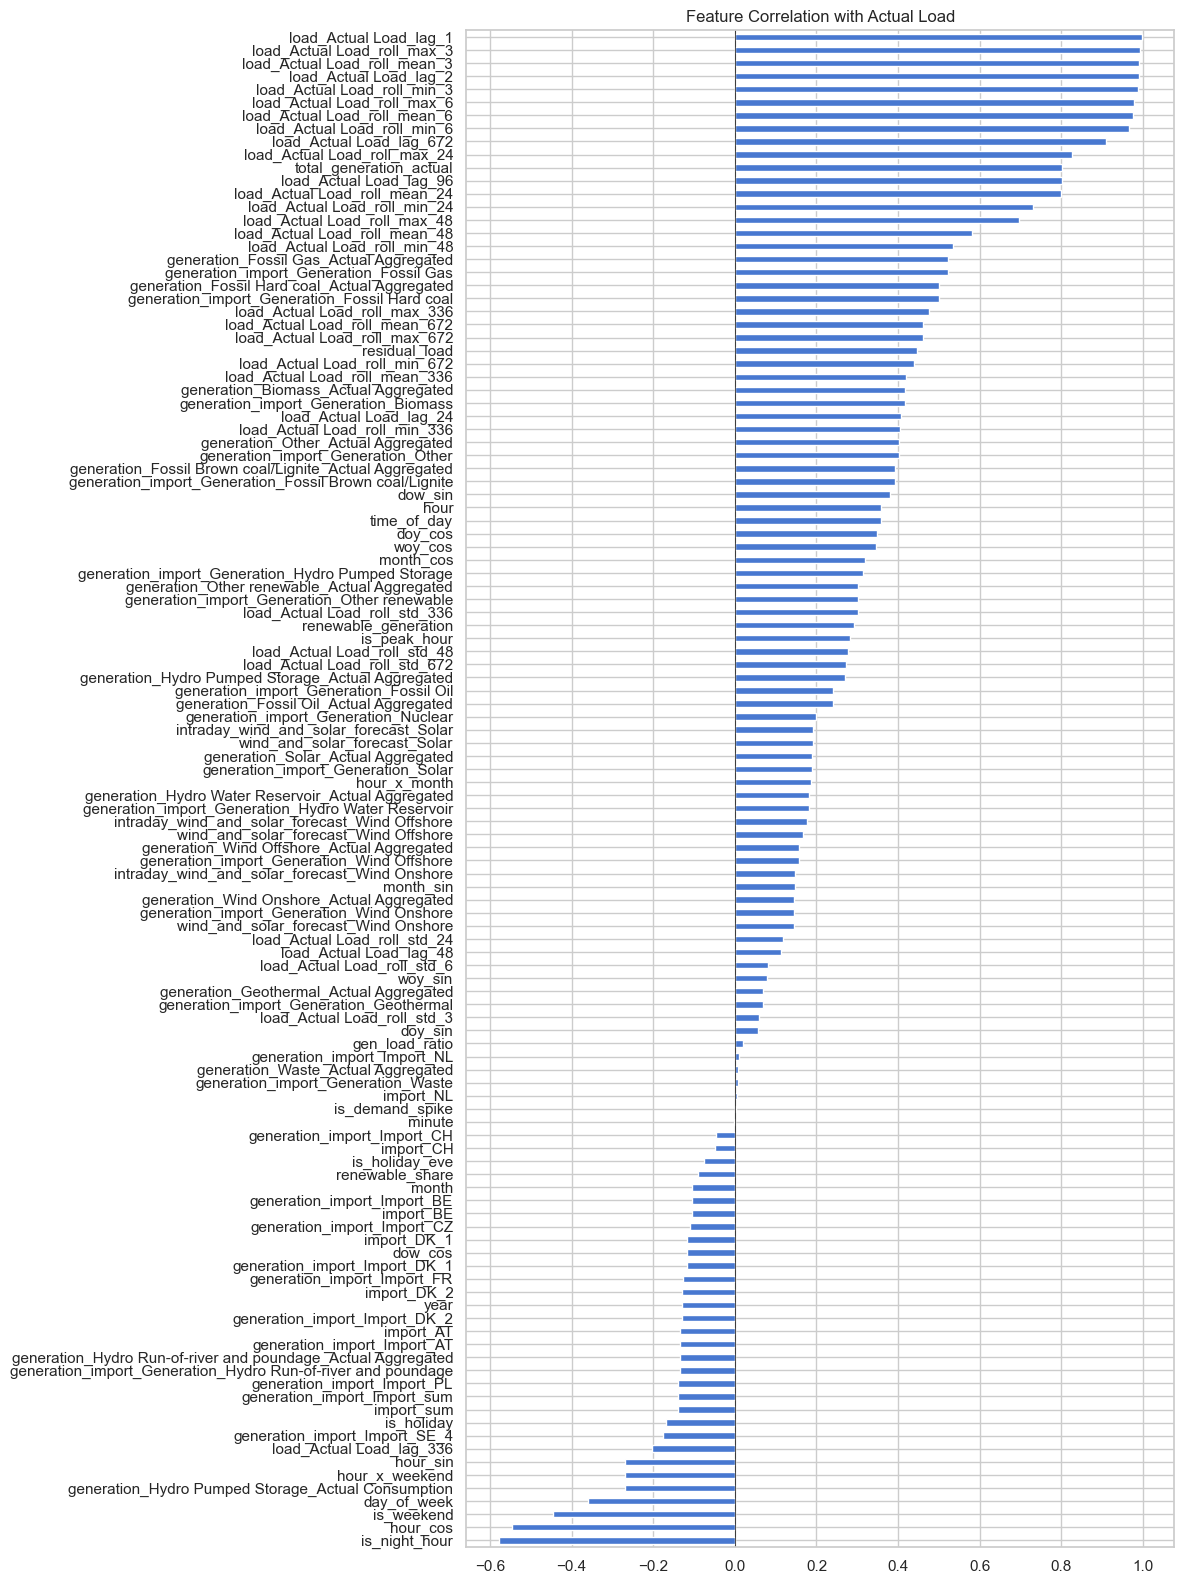

Top 10 positively correlated:
load_Actual Load_roll_max_24    0.826476
load_Actual Load_lag_672        0.910020
load_Actual Load_roll_min_6     0.965118
load_Actual Load_roll_mean_6    0.976475
load_Actual Load_roll_max_6     0.979533
load_Actual Load_roll_min_3     0.988947
load_Actual Load_lag_2          0.991323
load_Actual Load_roll_mean_3    0.991636
load_Actual Load_roll_max_3     0.992654
load_Actual Load_lag_1          0.997554
Name: load_Actual Load, dtype: float64

Top 10 negatively correlated:
is_night_hour                                        -0.579132
hour_cos                                             -0.545957
is_weekend                                           -0.445929
day_of_week                                          -0.360658
generation_Hydro Pumped Storage_Actual Consumption   -0.269620
hour_x_weekend                                       -0.269185
hour_sin                                             -0.268770
load_Actual Load_lag_336                         

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation of all features with target
corr = df_new.corr()[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(12, 16))
corr.plot(kind='barh', figsize=(12, 16))
plt.title('Feature Correlation with Actual Load')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print top and bottom correlators
print("Top 10 positively correlated:")
print(corr.tail(10))
print("\nTop 10 negatively correlated:")
print(corr.head(10))

In [51]:
corr_full = df_new.corr()[TARGET].drop(TARGET).dropna().sort_values()

# Feature strength summary
print(f"Total features: {len(corr_full)}")
print(f"Strong (>0.3 abs):   {(corr_full.abs() > 0.3).sum()}")
print(f"Moderate (0.1-0.3):  {((corr_full.abs() >= 0.1) & (corr_full.abs() <= 0.3)).sum()}")
print(f"Weak (<0.1 abs):     {(corr_full.abs() < 0.1).sum()}")

# Weak features — candidates to drop
weak = corr_full[corr_full.abs() < 0.05]
print(f"\nVery weak features (<0.05 correlation):")
print(weak)

Total features: 116
Strong (>0.3 abs):   49
Moderate (0.1-0.3):  50
Weak (<0.1 abs):     17

Very weak features (<0.05 correlation):
import_CH                            -0.048467
generation_import_Import_CH          -0.046888
minute                               -0.002183
is_demand_spike                       0.003427
import_NL                             0.006431
generation_import_Generation_Waste    0.007508
generation_Waste_Actual Aggregated    0.008314
generation_import_Import_NL           0.010169
gen_load_ratio                        0.020235
Name: load_Actual Load, dtype: float64


In [52]:
weak_all = corr_full[corr_full.abs() < 0.1].sort_values()
print("All weak features (<0.1 correlation):")
print(weak_all)

All weak features (<0.1 correlation):
renewable_share                           -0.090446
is_holiday_eve                            -0.076429
import_CH                                 -0.048467
generation_import_Import_CH               -0.046888
minute                                    -0.002183
is_demand_spike                            0.003427
import_NL                                  0.006431
generation_import_Generation_Waste         0.007508
generation_Waste_Actual Aggregated         0.008314
generation_import_Import_NL                0.010169
gen_load_ratio                             0.020235
doy_sin                                    0.057754
load_Actual Load_roll_std_3                0.058767
generation_import_Generation_Geothermal    0.068274
generation_Geothermal_Actual Aggregated    0.068301
woy_sin                                    0.079462
load_Actual Load_roll_std_6                0.080898
Name: load_Actual Load, dtype: float64


In [53]:
drop_features = [
    "renewable_share",
    "is_holiday_eve",
    "import_CH",
    "generation_import_Import_CH",
    "minute",
    "generation_import_Generation_Waste",
    "import_NL",
    "generation_Waste_Actual Aggregated",
    "generation_import_Import_NL",
    "load_Actual Load_roll_std_3",
    "generation_import_Generation_Geothermal",
    "generation_Geothermal_Actual Aggregated",
    "load_Actual Load_roll_std_6"
]

df_new.drop(columns=drop_features, inplace=True)
print(f"Final features: {df_new.shape[1]}")

Final features: 104


In [54]:
output_dir = 'artifacts/preprocessed'
os.makedirs(output_dir, exist_ok=True)

df_new.to_parquet(output_dir + '/power_consumption_preprocessed.parquet') 